In [1]:
!pip install -q datasets pandas matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

d:\sentiment and sarcasm analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset = load_dataset("unswnlporg/BESSTIE")

print(dataset)

Generating test split: 100%|██████████| 5054/5054 [00:00<00:00, 255114.96 examples/s]


DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'variety', 'source', 'task'],
        num_rows: 17760
    })
    validation: Dataset({
        features: ['text', 'label', 'variety', 'source', 'task'],
        num_rows: 2428
    })
    test: Dataset({
        features: ['text', 'label', 'variety', 'source', 'task'],
        num_rows: 5054
    })
})


In [5]:
print(dataset["train"].column_names)
print(dataset["train"][0])

['text', 'label', 'variety', 'source', 'task']
{'text': "This was one of the best dishes I've EVER had! I have very high standards, and I also comparing to Melbourne cafes. There was a generous amount of mushrooms, perfectly cooked. There was an AMAZING onion jam thing, the truffle mayo was absolutely incredible! Very reasonably priced. I asked for sourdough instead of brioche which was happily done, but the bread was very soggy when I got the plate. I could move to Mackay just for this And as vegetarians, I REALLY appreciate you for not charging us the extra 4 for replacing the bacon with avo in your ' bacon and eggs '. 80 % of places make you pay for substituting the meat for vegetables:", 'label': 1, 'variety': 'en-AU', 'source': 'Google', 'task': 'Sentiment'}


In [6]:
train_df = dataset["train"].to_pandas()
valid_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

train_df["split"] = "train"
valid_df["split"] = "validation"
test_df["split"] = "test"

df = pd.concat([train_df, valid_df, test_df], ignore_index=True)

print(df.shape)
df.head()

(25242, 6)


,text,label,variety,source,task,split
0,This was one of the best dishes I've EVER had!...,1,en-AU,Google,Sentiment,train
1,This Mexican restaurant in Penrith is a great ...,1,en-AU,Google,Sentiment,train
2,"This was not to bad, I ordered the big pork ri...",1,en-AU,Google,Sentiment,train
3,Clean cool and a nice smaller casino to check ...,1,en-AU,Google,Sentiment,train
4,Well set out. Great areas to enjoy. Good food ...,1,en-AU,Google,Sentiment,train


In [7]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

Number of rows: 25242
Number of columns: 6

Columns:
Index(['text', 'label', 'variety', 'source', 'task', 'split'], dtype='str')

Missing values:
text       0
label      0
variety    0
source     0
task       0
split      0
dtype: int64


In [8]:
df.sample(10, random_state=42)

,text,label,variety,source,task,split
16598,Really not a bad place for a quick cheap meal ...,0,en-UK,Google,Sarcasm,train
12932,"Pizza slice was nice, but not very warm. Coffe...",1,en-UK,Google,Sentiment,train
21718,NZ in May isn't going to provide nice beach we...,0,en-AU,Reddit,Sarcasm,test
15342,I love this McDonald but I not sure what going...,0,en-UK,Google,Sarcasm,train
19647,Gorgeous college with lovely places to walk ar...,1,en-UK,Google,Sentiment,validation
18703,One Of My Most Fav Pizza Place in Town. They S...,1,en-IN,Google,Sentiment,validation
18770,Yes she got gangubai as replacement,0,en-IN,Reddit,Sentiment,validation
2153,Got elevators or car stack parks. These things...,0,en-AU,Reddit,Sentiment,train
19511,"Been here first time but glad I made it. now, ...",1,en-UK,Google,Sentiment,validation
12094,"Unrivalled value on quality farmhouse pizza, b...",1,en-UK,Google,Sentiment,train


In [10]:
split_count = df["split"].value_counts()

print(split_count)

split
train         17760
test           5054
validation     2428
Name: count, dtype: int64


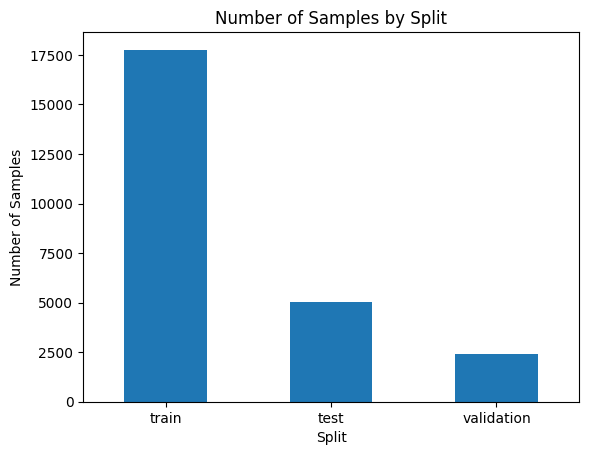

In [11]:
split_count.plot(kind="bar")

plt.title("Number of Samples by Split")
plt.xlabel("Split")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

In [12]:
task_count = df["task"].value_counts()

print(task_count)

task
Sarcasm      12641
Sentiment    12601
Name: count, dtype: int64


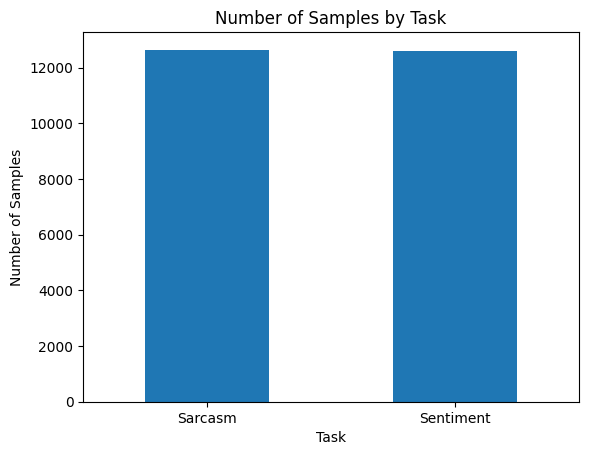

In [13]:
task_count.plot(kind="bar")

plt.title("Number of Samples by Task")
plt.xlabel("Task")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

In [14]:
label_count = df.groupby(["task", "label"]).size()

print(label_count)

task       label
Sarcasm    0        10827
           1         1814
Sentiment  0         6355
           1         6246
dtype: int64


In [ ]:
sentiment_df = df[df["task"] == "Sentiment"].copy()
sarcasm_df = df[df["task"] == "Sarcasm"].copy()

print("Sentiment data:", sentiment_df.shape)
print("Sarcasm data:", sarcasm_df.shape)

Sentiment data: (0, 6)
Sarcasm data: (0, 6)


In [36]:
sentiment_label_count = sentiment_df["label"].value_counts()

print(sentiment_label_count)

Series([], Name: count, dtype: int64)


In [42]:
sarcasm_label_count = sarcasm_df["label"].value_counts()

print(sarcasm_label_count)

Series([], Name: count, dtype: int64)


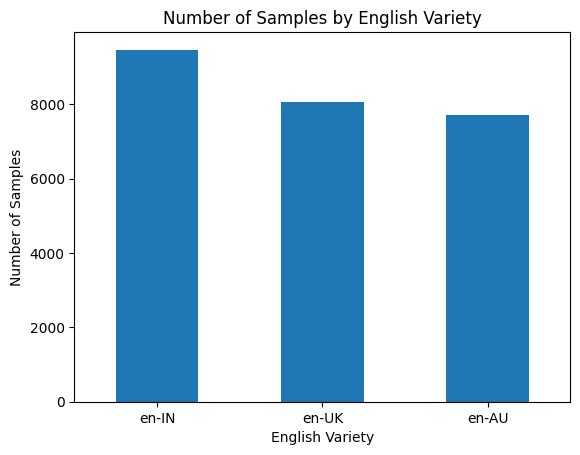

In [41]:
variety_count.plot(kind="bar")

plt.title("Number of Samples by English Variety")
plt.xlabel("English Variety")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

In [18]:
variety_task_count = df.groupby(["task", "variety"]).size()

print(variety_task_count)

task       variety
Sarcasm    en-AU      3851
           en-IN      4736
           en-UK      4054
Sentiment  en-AU      3851
           en-IN      4736
           en-UK      4014
dtype: int64


In [19]:
source_count = df["source"].value_counts()

print(source_count)

source
Reddit    12697
Google    12545
Name: count, dtype: int64


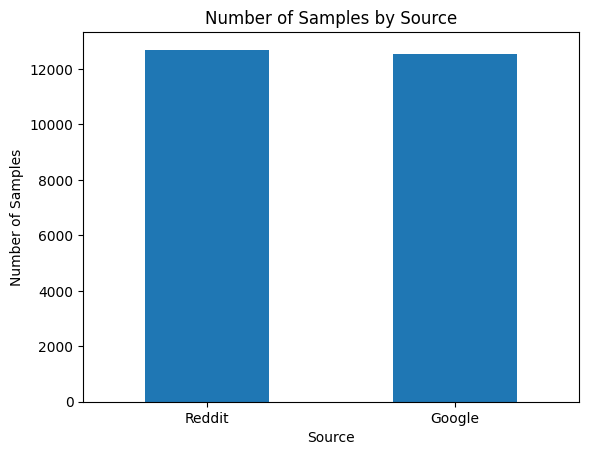

In [20]:
source_count.plot(kind="bar")

plt.title("Number of Samples by Source")
plt.xlabel("Source")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

In [21]:
df["text_length"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

df[["text", "text_length", "word_count"]].head()

,text,text_length,word_count
0,This was one of the best dishes I've EVER had!...,641,117
1,This Mexican restaurant in Penrith is a great ...,576,93
2,"This was not to bad, I ordered the big pork ri...",309,62
3,Clean cool and a nice smaller casino to check ...,251,46
4,Well set out. Great areas to enjoy. Good food ...,138,26


In [22]:
df[["text_length", "word_count"]].describe()

,text_length,word_count
count,25242.000000,25242.000000
mean,273.514817,49.453847
std,336.921582,58.948407
min,1.000000,1.000000
25%,90.000000,16.000000
50%,189.000000,34.000000
75%,341.000000,62.000000
max,8537.000000,1412.000000


In [23]:
avg_words_by_task = df.groupby("task")["word_count"].mean()

print(avg_words_by_task)

task
Sarcasm      49.454315
Sentiment    49.453377
Name: word_count, dtype: float64


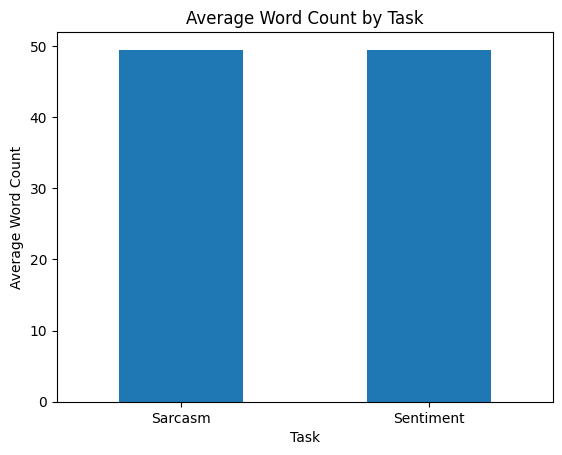

In [24]:
avg_words_by_task.plot(kind="bar")

plt.title("Average Word Count by Task")
plt.xlabel("Task")
plt.ylabel("Average Word Count")
plt.xticks(rotation=0)
plt.show()

In [26]:
sentiment_percent = sentiment_df["label"].value_counts(normalize=True) * 100

print(sentiment_percent)

Series([], Name: proportion, dtype: float64)


In [27]:
sarcasm_percent = sarcasm_df["label"].value_counts(normalize=True) * 100

print(sarcasm_percent)

Series([], Name: proportion, dtype: float64)


In [28]:
import os

os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

In [43]:
split_count.to_csv("outputs/tables/split_count.csv")
task_count.to_csv("outputs/tables/task_count.csv")
sentiment_label_count.to_csv("outputs/tables/sentiment_label_count.csv")
sarcasm_label_count.to_csv("outputs/tables/sarcasm_label_count.csv")
variety_count.to_csv("outputs/tables/variety_count.csv")
source_count.to_csv("outputs/tables/source_count.csv")

print("Saved all tables.")

Saved all tables.


In [44]:
df.to_csv("outputs/besstie_all_data.csv", index=False)
sentiment_df.to_csv("outputs/sentiment_data.csv", index=False)
sarcasm_df.to_csv("outputs/sarcasm_data.csv", index=False)

print("Saved data files.")

Saved data files.


In [45]:
print("Week 1 Observations")
print("-------------------")

print("Total samples:", len(df))
print("Train samples:", len(train_df))
print("Validation samples:", len(valid_df))
print("Test samples:", len(test_df))

print("\nTasks:")
print(task_count)

print("\nEnglish varieties:")
print(variety_count)

print("\nSources:")
print(source_count)

print("\nSentiment labels:")
print(sentiment_label_count)

print("\nSarcasm labels:")
print(sarcasm_label_count)

Week 1 Observations
-------------------
Total samples: 25242
Train samples: 17760
Validation samples: 2428
Test samples: 5054

Tasks:
task
Sarcasm      12641
Sentiment    12601
Name: count, dtype: int64

English varieties:
variety
en-IN    9472
en-UK    8068
en-AU    7702
Name: count, dtype: int64

Sources:
source
Reddit    12697
Google    12545
Name: count, dtype: int64

Sentiment labels:
Series([], Name: count, dtype: int64)

Sarcasm labels:
Series([], Name: count, dtype: int64)
